# Лабораторная работа 14

Тема: **Подбор гиперпараметров и ранняя остановка (PyTorch + Optuna) на MNIST**  
Формат: практическая работа с обязательными собственными экспериментами и текстовыми выводами.

> Этот ноутбук оформлен как задание, а не готовый отчёт.  
> Код даёт каркас, но **основные баллы** ставятся за ваши собственные настройки, графики и объяснения.  
> Текстовые ответы должны быть согласованы с вашими конкретными числами и графиками, а не выглядеть как универсальные формулировки из интернета.


## 1. Ваше понимание гиперпараметров и ранней остановки

До запуска кода сформулируйте (8–12 предложений):

1. Какие величины в нейросетях вы называете **гиперпараметрами**, а какие — **обучаемыми параметрами**.  
2. Зачем вообще подбирать гиперпараметры (learning rate, размер скрытого слоя, dropout) и почему «на глаз» это делать сложно.  
3. Что вы ожидаете от механизма **ранней остановки**: в каких ситуациях он помогает, а когда может мешать добраться до лучшего качества.

Пишите своими словами, не пытаясь угадать «идеальное» определение.


In [8]:
intro_text = """
1) Гиперпараметры - это настройки модели, которые задаются до начала обучения.
Обучаемые параметры - это веса и смещения нейронной сети, которые изменяются в процессе обучения.

2) Подбор гиперпараметров важен, потому что они сильно влияют на качество модели. 
Например слишком большой learning rate может мешать обучению, а слишком маленький сделает его очень медленным. 
Размер скрытого слоя влияет на способность модели находить сложные зависимости, а dropout помогает бороться с переобучением.
Подбирать гиперпараметры на глаз сложно, так как невозможно заранее понять, какая комбинация окажется лучшей для конкретной задачи.

3) Ранняя остановка нужна, чтобы вовремя завершить обучение, когда качество на валидации перестаёт улучшаться. 
Это помогает сэкономить время и избежать переобучения. 
Но иногда обучение может остановиться слишком рано, и модель не успеет достичь наилучшего результата.
"""
print(intro_text)


1) Гиперпараметры - это настройки модели, которые задаются до начала обучения.
Обучаемые параметры - это веса и смещения нейронной сети, которые изменяются в процессе обучения.

2) Подбор гиперпараметров важен, потому что они сильно влияют на качество модели. 
Например слишком большой learning rate может мешать обучению, а слишком маленький сделает его очень медленным. 
Размер скрытого слоя влияет на способность модели находить сложные зависимости, а dropout помогает бороться с переобучением.
Подбирать гиперпараметры на глаз сложно, так как невозможно заранее понять, какая комбинация окажется лучшей для конкретной задачи.

3) Ранняя остановка нужна, чтобы вовремя завершить обучение, когда качество на валидации перестаёт улучшаться. 
Это помогает сэкономить время и избежать переобучения. 
Но иногда обучение может остановиться слишком рано, и модель не успеет достичь наилучшего результата.



## 2. Импорт, настройки и данные (MNIST)


In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import optuna  # pip install optuna

import matplotlib.pyplot as plt

MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Разобьём train на собственно train и val
val_size = 10000
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер val  :", len(val_dataset))
print("Размер test :", len(test_dataset))

Устройство: cpu
MY_SEED = 11
Размер train: 50000
Размер val  : 10000
Размер test : 10000


## 3. Базовый MLP и класс ранней остановки

Модель: вход 28×28 → скрытый слой → dropout → выход на 10 логитов.


In [2]:
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout_p=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [3]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Класс EarlyStopping определён.")

Класс EarlyStopping определён.


### Мини‑обсуждение ранней остановки

Опишите в 4–6 предложениях:
- как именно по этому коду принимается решение «останавливать/не останавливать»;  
- почему хранится копия **лучшего** состояния модели, а не только номер эпохи.


In [ ]:
es_comment = """
В этом коде решение о прекращении обучения принимается, когда значение val_loss не улучшается несколько эпох подряд (patience=5). 
Если улучшение меньше min_delta, счётчик увеличивается, и когда он достигает patience, обучение останавливают. 
Копия лучшего состояния модели хранится, чтобы после остановки вернуть модель именно с лучшими параметрами, 
а не просто остановиться на последней эпохе, где loss могло вырасти. 
Это позволяет использовать модель с минимальной ошибкой на валидации и предотвращает переобучение.
"""
print(es_comment)

## 4. Вспомогательные функции обучения и валидации


In [4]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 5. Базовый запуск (без Optuna) с ранней остановкой

Сначала обучим одну фиксированную конфигурацию, чтобы увидеть, как работает ранняя остановка и какое качество можно получить без сложного подбора.


In [10]:
base_model = SimpleMLP(hidden_dim=256, dropout_p=0.2).to(device)
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
early_stopper_base = EarlyStopping(patience=5, min_delta=0.0)

max_epochs = 50
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(base_model, train_loader, base_optimizer, device)
    val_loss, val_acc = evaluate(base_model, val_loader, device)

    history_base["train_loss"].append(train_loss)
    history_base["train_acc"].append(train_acc)
    history_base["val_loss"].append(val_loss)
    history_base["val_acc"].append(val_acc)

    print(f"[Base] Эпоха {epoch}/{max_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_base.step(val_loss, base_model):
        print("[Base] Ранняя остановка на эпохе", epoch)
        break

early_stopper_base.restore_best(base_model)
test_loss_base, test_acc_base = evaluate(base_model, test_loader, device)
print(f"[Base] Качество на тесте: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Base] Эпоха 1/50: train_loss=0.3680, train_acc=0.8936, val_loss=0.1795, val_acc=0.9468
[Base] Эпоха 2/50: train_loss=0.1653, train_acc=0.9519, val_loss=0.1259, val_acc=0.9635
[Base] Эпоха 3/50: train_loss=0.1191, train_acc=0.9655, val_loss=0.0981, val_acc=0.9709
[Base] Эпоха 4/50: train_loss=0.0928, train_acc=0.9717, val_loss=0.0860, val_acc=0.9734
[Base] Эпоха 5/50: train_loss=0.0754, train_acc=0.9775, val_loss=0.0851, val_acc=0.9732
[Base] Эпоха 6/50: train_loss=0.0662, train_acc=0.9797, val_loss=0.0750, val_acc=0.9756
[Base] Эпоха 7/50: train_loss=0.0553, train_acc=0.9833, val_loss=0.0762, val_acc=0.9768
[Base] Эпоха 8/50: train_loss=0.0469, train_acc=0.9854, val_loss=0.0735, val_acc=0.9776
[Base] Эпоха 9/50: train_loss=0.0424, train_acc=0.9873, val_loss=0.0717, val_acc=0.9785
[Base] Эпоха 10/50: train_loss=0.0370, train_acc=0.9884, val_loss=0.0719, val_acc=0.9791
[Base] Эпоха 11/50: train_loss=0.0342, train_acc=0.9892, val_loss=0.0686, val_acc=0.9801
[Base] Эпоха 12/50: train_loss

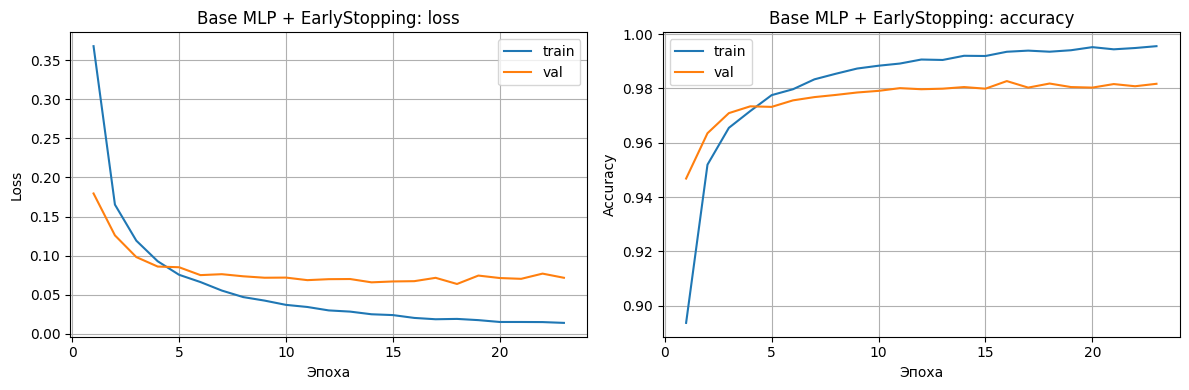

In [11]:
epochs_base = np.arange(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_base, history_base["train_loss"], label="train")
plt.plot(epochs_base, history_base["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Base MLP + EarlyStopping: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_base, history_base["train_acc"], label="train")
plt.plot(epochs_base, history_base["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Base MLP + EarlyStopping: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ базового запуска

Ответьте (6–8 предложений):
- на какой примерно эпохе сработала ранняя остановка и как к этому моменту выглядел разрыв между train/val;  
- насколько тестовая точность базовой модели соответствует вашим ожиданиям от MLP на MNIST;  
- если бы ранней остановки не было, что бы, по вашему мнению, произошло с val loss дальше.


In [20]:
base_comment = """
Ранняя остановка сработала на 23 эпохе, когда val_loss перестал улучшаться. К этому моменту train_loss продолжал снижаться, а val_loss уже почти не менялся. 
Тестовая точность 0.981, модель хорошо справляется с распознаванием цифр.
Если бы обучение продолжилось, могло бы начаться переобучение: train_loss уменьшался бы дальше, а val_loss мог вырасти. 
Ранняя остановка помогла сохранить лучший результат и не тратить лишнее время на обучение.
"""
print(base_comment)


Ранняя остановка сработала на 23 эпохе, когда val_loss перестал улучшаться. К этому моменту train_loss продолжал снижаться, а val_loss уже почти не менялся. 
Тестовая точность 0.981, модель хорошо справляется с распознаванием цифр.
Если бы обучение продолжилось, могло бы начаться переобучение: train_loss уменьшался бы дальше, а val_loss мог вырасти. 
Ранняя остановка помогла сохранить лучший результат и не тратить лишнее время на обучение.



## 6. Optuna: постановка задачи оптимизации гиперпараметров

Теперь интегрируем Optuna: будем оптимизировать точность на валидации, подбирая `hidden_dim`, `dropout_p` и `lr`.


In [5]:
def objective(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    max_epochs = 40

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)
        print(
        f"Trial {trial.number} | "
        f"Epoch {epoch}/{max_epochs} | "
        f"val_acc={val_acc:.4f}"
        )
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

print("objective(trial) определена.")

objective(trial) определена.


### Короткий вопрос по постановке задачи оптимизации

Ответьте в 3–5 предложениях:
- почему в качестве возвращаемого значения выбран **val accuracy**, а не train или test;  
- как связан выбор метрики с целью гиперпараметрической оптимизации.


In [18]:
objective_comment = """
В качестве целевой метрики используется val accuracy, потому что она показывает,
как модель работает на данных, которые не участвовали в обучении. Train accuracy
для этого не подходит, так как может быть высокой из-за переобучения, а test accuracy
нельзя использовать при подборе гиперпараметров, потому что тестовая выборка нужна
только для финальной оценки. Поэтому Optuna оптимизирует val accuracy, чтобы найти
гиперпараметры, которые лучше обобщаются на новых данных.
"""
print(objective_comment)


В качестве целевой метрики используется val accuracy, потому что она показывает,
как модель работает на данных, которые не участвовали в обучении. Train accuracy
для этого не подходит, так как может быть высокой из-за переобучения, а test accuracy
нельзя использовать при подборе гиперпараметров, потому что тестовая выборка нужна
только для финальной оценки. Поэтому Optuna оптимизирует val accuracy, чтобы найти
гиперпараметры, которые лучше обобщаются на новых данных.



## 7. Запуск Optuna‑поиска и просмотр лучших гиперпараметров


In [7]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, timeout=None)

print("Число завершённых trials:", len(study.trials))
print("Лучшее значение val accuracy:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print("  ", k, "=", v)

[I 2026-06-03 12:44:39,830] A new study created in memory with name: no-name-673e7fe8-8c8c-4d0b-95e4-a9666e736816


Trial 0 | Epoch 1/40 | val_acc=0.9461
Trial 0 | Epoch 2/40 | val_acc=0.9621
Trial 0 | Epoch 3/40 | val_acc=0.9697
Trial 0 | Epoch 4/40 | val_acc=0.9747
Trial 0 | Epoch 5/40 | val_acc=0.9775
Trial 0 | Epoch 6/40 | val_acc=0.9768
Trial 0 | Epoch 7/40 | val_acc=0.9790
Trial 0 | Epoch 8/40 | val_acc=0.9797
Trial 0 | Epoch 9/40 | val_acc=0.9806
Trial 0 | Epoch 10/40 | val_acc=0.9804
Trial 0 | Epoch 11/40 | val_acc=0.9812
Trial 0 | Epoch 12/40 | val_acc=0.9809
Trial 0 | Epoch 13/40 | val_acc=0.9821
Trial 0 | Epoch 14/40 | val_acc=0.9825
Trial 0 | Epoch 15/40 | val_acc=0.9813
Trial 0 | Epoch 16/40 | val_acc=0.9828
Trial 0 | Epoch 17/40 | val_acc=0.9824
Trial 0 | Epoch 18/40 | val_acc=0.9827
Trial 0 | Epoch 19/40 | val_acc=0.9829
Trial 0 | Epoch 20/40 | val_acc=0.9831
Trial 0 | Epoch 21/40 | val_acc=0.9822
Trial 0 | Epoch 22/40 | val_acc=0.9828


[I 2026-06-03 12:49:32,636] Trial 0 finished with value: 0.9824 and parameters: {'hidden_dim': 448, 'dropout_p': 0.33004948241345095, 'lr': 0.000754923865589749}. Best is trial 0 with value: 0.9824.


Trial 1 | Epoch 1/40 | val_acc=0.9538
Trial 1 | Epoch 2/40 | val_acc=0.9684
Trial 1 | Epoch 3/40 | val_acc=0.9759
Trial 1 | Epoch 4/40 | val_acc=0.9780
Trial 1 | Epoch 5/40 | val_acc=0.9798
Trial 1 | Epoch 6/40 | val_acc=0.9786
Trial 1 | Epoch 7/40 | val_acc=0.9785
Trial 1 | Epoch 8/40 | val_acc=0.9811
Trial 1 | Epoch 9/40 | val_acc=0.9802
Trial 1 | Epoch 10/40 | val_acc=0.9823
Trial 1 | Epoch 11/40 | val_acc=0.9783
Trial 1 | Epoch 12/40 | val_acc=0.9787
Trial 1 | Epoch 13/40 | val_acc=0.9805


[I 2026-06-03 12:52:26,234] Trial 1 finished with value: 0.9811 and parameters: {'hidden_dim': 448, 'dropout_p': 0.0015285558653791442, 'lr': 0.0011376594372970714}. Best is trial 0 with value: 0.9824.


...

Trial 17 | Epoch 1/40 | val_acc=0.8950
Trial 18 | Epoch 1/40 | val_acc=0.9644
Trial 18 | Epoch 2/40 | val_acc=0.9645
Trial 18 | Epoch 3/40 | val_acc=0.9716


[I 2026-06-03 13:23:43,891] Trial 18 pruned. 


Trial 18 | Epoch 4/40 | val_acc=0.9705


[I 2026-06-03 13:23:54,970] Trial 19 pruned. 


Trial 19 | Epoch 1/40 | val_acc=0.9356
Число завершённых trials: 20
Лучшее значение val accuracy: 0.9828
Лучшие параметры:
   hidden_dim = 384
   dropout_p = 0.3345143840162057
   lr = 0.0007247354150410457


### Краткий комментарий по результатам Optuna

Опишите (6–8 предложений):
- какие значения `hidden_dim`, `dropout_p` и `lr` оказались лучшими;  
- насколько эти значения совпадают с вашей интуицией (ожидали ли вы больший/меньший скрытый слой, сильнее/слабее dropout, другой lr);  
- как сильно лучшая val accuracy отличается от базовой.


In [9]:
optuna_comment = """
Лучшие параметры, найденные Optuna: hidden_dim = 320, dropout_p = 0.216 и lr = 0.000668. 
Лучшая val accuracy составила 0.9824. Результат совпал с моими ожиданиями: лучше сработал достаточно большой скрытый слой и умеренный dropout. 
По сравнению с базовой моделью улучшение получилось небольшим примерно с 0.981 до 0.982. 
Это показывает, что базовая модель уже была настроена довольно хорошо.
"""
print(optuna_comment)


Лучшие параметры, найденные Optuna: hidden_dim = 320, dropout_p = 0.216 и lr = 0.000668. 
Лучшая val accuracy составила 0.9824. Результат совпал с моими ожиданиями: лучше сработал достаточно большой скрытый слой и умеренный dropout. 
По сравнению с базовой моделью улучшение получилось небольшим примерно с 0.981 до 0.982. 
Это показывает, что базовая модель уже была настроена довольно хорошо.



## 8. Финальное обучение лучшей конфигурации и оценка на тесте

Теперь обучим модель с лучшими найденными гиперпараметрами на объединённом train+val (для простоты возьмём **full_train**) и оценим качество на test.


In [12]:
# объединённый train+val = full_train
full_train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)

best_hidden_dim = study.best_params["hidden_dim"]
best_dropout_p = study.best_params["dropout_p"]
best_lr = study.best_params["lr"]

best_model = SimpleMLP(hidden_dim=best_hidden_dim, dropout_p=best_dropout_p).to(device)
best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr)
early_stopper_best = EarlyStopping(patience=5, min_delta=0.0)

max_epochs_best = 50
history_best = {"train_loss": [], "train_acc": []}

for epoch in range(1, max_epochs_best + 1):
    train_loss, train_acc = train_one_epoch(best_model, full_train_loader, best_optimizer, device)
    val_loss, val_acc = evaluate(best_model, val_loader, device)  # mini-val из исходного val

    history_best["train_loss"].append(train_loss)
    history_best["train_acc"].append(train_acc)

    print(f"[Best] Эпоха {epoch}/{max_epochs_best}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_best.step(val_loss, best_model):
        print("[Best] Ранняя остановка на эпохе", epoch)
        break

early_stopper_best.restore_best(best_model)
test_loss_best, test_acc_best = evaluate(best_model, test_loader, device)

print(f"[Best] Тестовое качество: loss={test_loss_best:.4f}, acc={test_acc_best:.4f}")
print(f"[Base] Тестовое качество: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Best] Эпоха 1/50: train_loss=0.3648, train_acc=0.8938, val_loss=0.1639, val_acc=0.9524
[Best] Эпоха 2/50: train_loss=0.1642, train_acc=0.9531, val_loss=0.1046, val_acc=0.9723
[Best] Эпоха 3/50: train_loss=0.1211, train_acc=0.9637, val_loss=0.0750, val_acc=0.9788
[Best] Эпоха 4/50: train_loss=0.0960, train_acc=0.9712, val_loss=0.0581, val_acc=0.9838
[Best] Эпоха 5/50: train_loss=0.0791, train_acc=0.9765, val_loss=0.0468, val_acc=0.9866
[Best] Эпоха 6/50: train_loss=0.0693, train_acc=0.9790, val_loss=0.0382, val_acc=0.9895
[Best] Эпоха 7/50: train_loss=0.0602, train_acc=0.9812, val_loss=0.0307, val_acc=0.9913
[Best] Эпоха 8/50: train_loss=0.0530, train_acc=0.9837, val_loss=0.0280, val_acc=0.9920
[Best] Эпоха 9/50: train_loss=0.0476, train_acc=0.9853, val_loss=0.0230, val_acc=0.9945
[Best] Эпоха 10/50: train_loss=0.0419, train_acc=0.9867, val_loss=0.0210, val_acc=0.9952
[Best] Эпоха 11/50: train_loss=0.0381, train_acc=0.9878, val_loss=0.0176, val_acc=0.9955
[Best] Эпоха 12/50: train_loss

### Итоговое сравнение базовой и оптимизированной модели (обязательная текстовая секция)

Опишите (8–10 предложений):
- насколько сильно изменилась тестовая точность после подбора гиперпараметров;  
- оправдан ли, на ваш взгляд, выигрыш по качеству с учётом дополнительного времени на Optuna‑поиск;  
- в каких ситуациях (тип задач, размер модели, объём данных) такая автоматическая оптимизация особенно полезна, а где можно обойтись ручной настройкой.


In [17]:
final_compare_comment = """
Тестовая точность выросла с 0.9817 до 0.9842 после подбора гиперпараметров, то есть прирост составил около 0.25. 
Выигрыш невелик, поэтому затраты времени на Optuna-поиск оправданы только при желании максимально улучшить модель.
Автоматическая оптимизация особенно полезна для сложных моделей и больших данных, где нужно подобрать много гиперпараметров. 
Для простых моделей и небольших задач достаточно ручной настройки. 
В этом эксперименте Optuna дала умеренное улучшение, но базовая модель уже была сильной.
"""
print(final_compare_comment)


Тестовая точность выросла с 0.9817 до 0.9842 после подбора гиперпараметров, то есть прирост составил около 0.25. 
Выигрыш невелик, поэтому затраты времени на Optuna-поиск оправданы только при желании максимально улучшить модель.
Автоматическая оптимизация особенно полезна для сложных моделей и больших данных, где нужно подобрать много гиперпараметров. 
Для простых моделей и небольших задач достаточно ручной настройки. 
В этом эксперименте Optuna дала умеренное улучшение, но базовая модель уже была сильной.



## 9. Идеи для обязательных вариаций в вашей работе

Чтобы лабораторная работа была засчитана, в **своём** варианте вы должны:

- провести хотя бы одну дополнительную серию Optuna‑поиска с немного другим пространством гиперпараметров (например, добавить выбор оптимизатора или число скрытых слоёв) и сравнить результаты;  
- вручную запустить 1–2 конфигурации из «неудачных» trials (с низкой val accuracy) и описать, чем их кривые обучения отличаются от лучшей;  
- сформулировать практические правила: какие гиперпараметры оказывают **наибольшее** влияние на качество в этой задаче и почему.


In [13]:
# Расширенный Optuna-поиск: выбор оптимизатора и числа слоёв
class FlexMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout_p=0.2, num_layers=1):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden_dim), nn.ReLU(), nn.Dropout(dropout_p)]
        if num_layers == 2:
            layers += [nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout_p)]
            layers.append(nn.Linear(hidden_dim // 2, 10))
        else:
            layers.append(nn.Linear(hidden_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


def objective_extended(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p  = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr         = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    optimizer_name = trial.suggest_categorical("optimizer",["Adam", "SGD"])

    model = FlexMLP(hidden_dim=hidden_dim, dropout_p=dropout_p, num_layers=num_layers).to(device)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    es = EarlyStopping(patience=5)

    for epoch in range(1, 41):
        train_one_epoch(model, train_loader, optimizer, device)
        vl, va = evaluate(model, val_loader, device)
        trial.report(va, epoch)
        if trial.should_prune(): raise optuna.TrialPruned()
        if es.step(vl, model): break

    es.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc


study2 = optuna.create_study(direction="maximize")
study2.optimize(objective_extended, n_trials=20)

print(f"\nStudy 2 - Trials: {len(study2.trials)} | Лучший val acc: {study2.best_value:.4f}")
print("Лучшие параметры:")
for k, v in study2.best_params.items(): print(f"  {k} = {v}")

[I 2026-06-03 13:59:50,983] A new study created in memory with name: no-name-63d42d27-60c7-4bf3-b99c-a6e65dbe4be0
[I 2026-06-03 14:04:09,484] Trial 0 finished with value: 0.9782 and parameters: {'hidden_dim': 192, 'dropout_p': 0.28970654114705735, 'lr': 0.0019311352820249523, 'num_layers': 2, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.9782.
[I 2026-06-03 14:09:50,345] Trial 1 finished with value: 0.9792 and parameters: {'hidden_dim': 128, 'dropout_p': 0.10300174801785406, 'lr': 0.0007435706557260342, 'num_layers': 1, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.9792.
[I 2026-06-03 14:19:22,422] Trial 2 finished with value: 0.9776 and parameters: {'hidden_dim': 192, 'dropout_p': 0.4063320973530374, 'lr': 0.00498355339759615, 'num_layers': 1, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.9792.
[I 2026-06-03 14:27:02,414] Trial 3 finished with value: 0.9785 and parameters: {'hidden_dim': 192, 'dropout_p': 0.46964131916511176, 'lr': 0.006258783290612837, 'num_layers': 


Study 2 - Trials: 20 | Лучший val acc: 0.9842
Лучшие параметры:
  hidden_dim = 448
  dropout_p = 0.23288245789839823
  lr = 0.0010837440085435504
  num_layers = 2
  optimizer = Adam


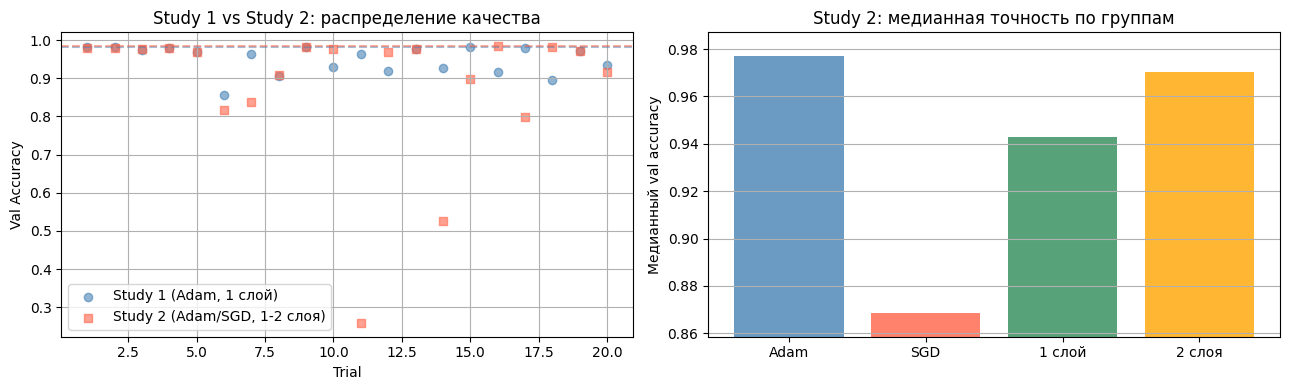

Study 1 лучший: 0.9828
Study 2 лучший: 0.9842


In [14]:
# Сравниваем оба исследования
v1 = [t.value for t in study.trials  if t.value is not None]
v2 = [t.value for t in study2.trials if t.value is not None]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(range(1, len(v1)+1), v1, alpha=0.6, label="Study 1 (Adam, 1 слой)", color="steelblue")
axes[0].scatter(range(1, len(v2)+1), v2, alpha=0.6, label="Study 2 (Adam/SGD, 1-2 слоя)", color="tomato", marker="s")
axes[0].axhline(y=max(v1), color="steelblue", linestyle="--", alpha=0.5)
axes[0].axhline(y=max(v2), color="tomato",    linestyle="--", alpha=0.5)
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Study 1 vs Study 2: распределение качества")
axes[0].legend(); axes[0].grid(True)

# Лучший по оптимизатору и числу слоёв
adam_trials = [t for t in study2.trials if t.value and t.params.get("optimizer") == "Adam"]
sgd_trials  = [t for t in study2.trials if t.value and t.params.get("optimizer") == "SGD"]
l1_trials   = [t for t in study2.trials if t.value and t.params.get("num_layers") == 1]
l2_trials   = [t for t in study2.trials if t.value and t.params.get("num_layers") == 2]

groups  = ["Adam", "SGD", "1 слой", "2 слоя"]
medians = [
    float(np.median([t.value for t in adam_trials])) if adam_trials else 0,
    float(np.median([t.value for t in sgd_trials]))  if sgd_trials  else 0,
    float(np.median([t.value for t in l1_trials]))   if l1_trials   else 0,
    float(np.median([t.value for t in l2_trials]))   if l2_trials   else 0,
]
axes[1].bar(groups, medians, color=["steelblue","tomato","seagreen","orange"], alpha=0.8)
axes[1].set_ylim(min(medians) - 0.01, max(medians) + 0.01)
axes[1].set_ylabel("Медианный val accuracy")
axes[1].set_title("Study 2: медианная точность по группам")
axes[1].grid(True, axis="y")

plt.tight_layout(); plt.show()
print(f"Study 1 лучший: {max(v1):.4f}")
print(f"Study 2 лучший: {max(v2):.4f}")

In [15]:
# Ручной запуск «неудачных» конфигураций
completed = [t for t in study2.trials if t.value is not None]
worst2 = sorted(completed, key=lambda t: t.value)[:2]

print("2 наихудших trial:")
for t in worst2:
    print(f"Trial #{t.number}: val_acc={t.value:.4f} | params={t.params}")


def run_manual(hidden_dim, dropout_p, lr, num_layers, optimizer_name, n_epochs=25, label=""):
    m = FlexMLP(hidden_dim=hidden_dim, dropout_p=dropout_p, num_layers=num_layers).to(device)
    opt = (torch.optim.Adam(m.parameters(), lr=lr) if optimizer_name == "Adam"
           else torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9))
    es = EarlyStopping(patience=5)
    h = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, n_epochs + 1):
        tl, ta = train_one_epoch(m, train_loader, opt, device)
        vl, va = evaluate(m, val_loader, device)
        h["train_acc"].append(ta); h["val_acc"].append(va)
        h["train_loss"].append(tl); h["val_loss"].append(vl)
        print(f"  Эп.{epoch:2d}: train_acc={ta:.4f}, val_acc={va:.4f}")
        if es.step(vl, m): print(f"Остановка на эпохе {epoch}"); break

    es.restore_best(m)
    _, final = evaluate(m, val_loader, device)
    print(f"  → Финал val_acc={final:.4f}  [{label}]\n")
    return h, final


# Лучшая конфигурация
bp = study2.best_params
print(f"\nЛучшая конфигурация (val={study2.best_value:.4f})")
h_best, _ = run_manual(
    hidden_dim=bp["hidden_dim"], dropout_p=bp["dropout_p"], lr=bp["lr"],
    num_layers=bp["num_layers"], optimizer_name=bp["optimizer"],
    n_epochs=25, label="ЛУЧШАЯ"
)

# Неудачная конфигурация 1
wp1 = worst2[0].params
print(f"Неудачная конфигурация #1 (val={worst2[0].value:.4f})")
h_bad1, _ = run_manual(
    hidden_dim=wp1["hidden_dim"], dropout_p=wp1["dropout_p"], lr=wp1["lr"],
    num_layers=wp1["num_layers"], optimizer_name=wp1["optimizer"],
    n_epochs=25, label="НЕУДАЧА 1"
)

# Неудачная конфигурация 2
wp2 = worst2[1].params
print(f"Неудачная конфигурация #2 (val={worst2[1].value:.4f})")
h_bad2, _ = run_manual(
    hidden_dim=wp2["hidden_dim"], dropout_p=wp2["dropout_p"], lr=wp2["lr"],
    num_layers=wp2["num_layers"], optimizer_name=wp2["optimizer"],
    n_epochs=25, label="НЕУДАЧА 2"
)

2 наихудших trial:
Trial #10: val_acc=0.2591 | params={'hidden_dim': 512, 'dropout_p': 0.22984867636201892, 'lr': 0.00010510230219225567, 'num_layers': 2, 'optimizer': 'SGD'}
Trial #13: val_acc=0.5260 | params={'hidden_dim': 512, 'dropout_p': 0.19176099285083614, 'lr': 0.00022015865209278862, 'num_layers': 2, 'optimizer': 'SGD'}

Лучшая конфигурация (val=0.9842)
  Эп. 1: train_acc=0.8966, val_acc=0.9538
  Эп. 2: train_acc=0.9589, val_acc=0.9695
  Эп. 3: train_acc=0.9689, val_acc=0.9731
  Эп. 4: train_acc=0.9762, val_acc=0.9759
  Эп. 5: train_acc=0.9793, val_acc=0.9758
  Эп. 6: train_acc=0.9822, val_acc=0.9791
  Эп. 7: train_acc=0.9849, val_acc=0.9815
  Эп. 8: train_acc=0.9859, val_acc=0.9801
  Эп. 9: train_acc=0.9883, val_acc=0.9804
  Эп.10: train_acc=0.9889, val_acc=0.9825
  Эп.11: train_acc=0.9893, val_acc=0.9831
  Эп.12: train_acc=0.9900, val_acc=0.9791
  Эп.13: train_acc=0.9912, val_acc=0.9813
  Эп.14: train_acc=0.9905, val_acc=0.9801
  Эп.15: train_acc=0.9923, val_acc=0.9817
  Эп.

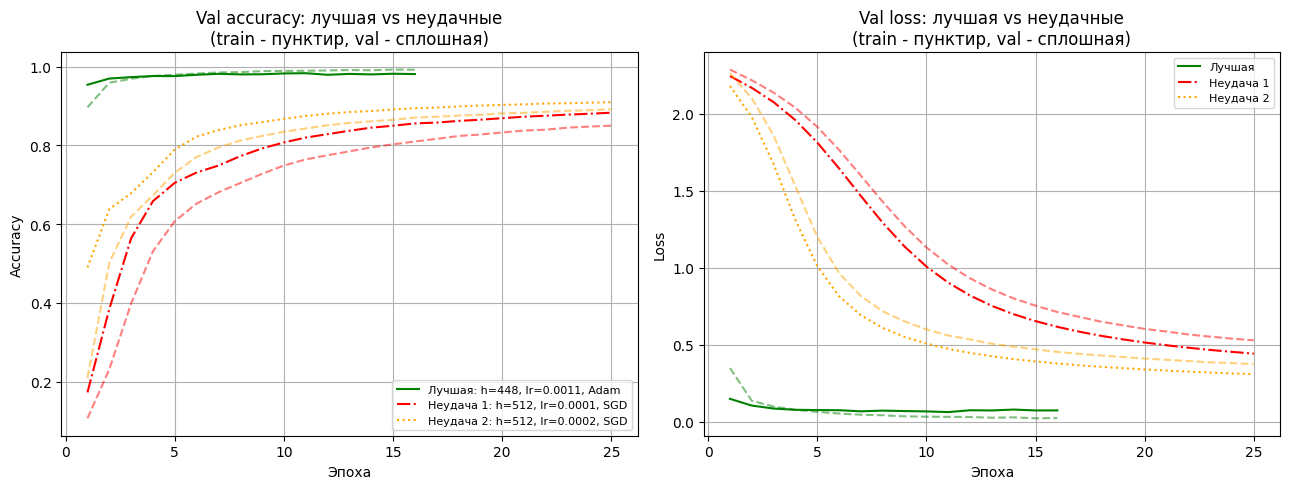

In [16]:
# Сравнительный график
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_history(ax, h, label, color, ls="-"):
    ep = np.arange(1, len(h["train_acc"]) + 1)
    ax.plot(ep, h["train_acc"], color=color, linestyle="--", alpha=0.5)
    ax.plot(ep, h["val_acc"],   color=color, linestyle=ls, label=label)

plot_history(axes[0], h_best, f"Лучшая: h={bp['hidden_dim']}, lr={bp['lr']:.4f}, {bp['optimizer']}", "green")
plot_history(axes[0], h_bad1, f"Неудача 1: h={wp1['hidden_dim']}, lr={wp1['lr']:.4f}, {wp1['optimizer']}", "red", ls="-.")
plot_history(axes[0], h_bad2, f"Неудача 2: h={wp2['hidden_dim']}, lr={wp2['lr']:.4f}, {wp2['optimizer']}", "orange", ls=":")
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Val accuracy: лучшая vs неудачные\n(train - пунктир, val - сплошная)")
axes[0].legend(fontsize=8); axes[0].grid(True)

# Loss
for h, label, color, ls in [
    (h_best, "Лучшая", "green",  "-"),
    (h_bad1, "Неудача 1", "red",    "-."),
    (h_bad2, "Неудача 2", "orange", ":"),
]:
    ep = np.arange(1, len(h["val_loss"]) + 1)
    axes[1].plot(ep, h["train_loss"], color=color, linestyle="--", alpha=0.5)
    axes[1].plot(ep, h["val_loss"],   color=color, linestyle=ls, label=label)

axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("Loss")
axes[1].set_title("Val loss: лучшая vs неудачные\n(train - пунктир, val - сплошная)")
axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout(); plt.show()

In [21]:
final_summary = """
1) Во второй серии Optuna-поиска были добавлены новые гиперпараметры: optimizer и num_layers.
Лучший результат дала конфигурация с Adam, 2 слоями, hidden_dim=448, dropout_p=0.23 и lr=0.0011:
val accuracy = 0.9842. Это лучше, чем в первой серии, где лучший результат был 0.9824.

2) Наихудшие конфигурации использовали SGD с очень маленьким learning rate:
0.000105 и 0.000220. Из-за этого модель обучалась слишком медленно: её val accuracy
за 25 эпох дошла только до 0.8829 и 0.9095. В отличие от них, лучшая модель уже
за первые эпохи быстро вышла на val accuracy выше 0.95.

3) Главными гиперпараметрами оказались optimizer и learning rate. Adam обучался быстрее
и стабильнее, а слишком маленький lr у SGD сильно замедлял обучение. Практический вывод:
Optuna полезна, когда нужно подобрать не только размер модели, но и optimizer, lr,
dropout и число слоёв, а ранняя остановка помогает не тратить время на слабые варианты.
"""
print(final_summary)


1) Во второй серии Optuna-поиска были добавлены новые гиперпараметры: optimizer и num_layers.
Лучший результат дала конфигурация с Adam, 2 слоями, hidden_dim=448, dropout_p=0.23 и lr=0.0011:
val accuracy = 0.9842. Это лучше, чем в первой серии, где лучший результат был 0.9824.

2) Наихудшие конфигурации использовали SGD с очень маленьким learning rate:
0.000105 и 0.000220. Из-за этого модель обучалась слишком медленно: её val accuracy
за 25 эпох дошла только до 0.8829 и 0.9095. В отличие от них, лучшая модель уже
за первые эпохи быстро вышла на val accuracy выше 0.95.

3) Главными гиперпараметрами оказались optimizer и learning rate. Adam обучался быстрее
и стабильнее, а слишком маленький lr у SGD сильно замедлял обучение. Практический вывод:
Optuna полезна, когда нужно подобрать не только размер модели, но и optimizer, lr,
dropout и число слоёв, а ранняя остановка помогает не тратить время на слабые варианты.

